# Trabajo Práctico III - Visión por Computadora I

Alumnos:
- Maximiliano Christener
- Ronald Uthurralt
- Luis David Díaz Charris
- Juan Pablo Skobalski

In [3]:
import cv2 as cv
import numpy as np
import supervision as sv
import os

**Preprocesamiento del pattern**

Como la mayor parte de las imagenes tienen el logo en blanco invertimos el pattern para mejorar el matching posterior. Croppeamos levemente el template para reducir matchings espúreos.

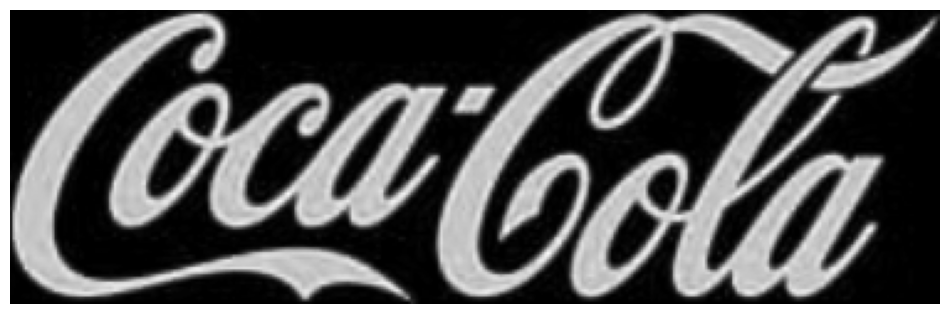

Medidas del pattern: (119, 376)


In [4]:
# Cargamos el pattern
patt_orig = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)

# Croppeamos levemente los bordes blancos
_, thresh = cv.threshold(patt_orig, 240, 255, cv.THRESH_BINARY_INV)
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
x, y, w, h = cv.boundingRect(np.vstack(contours))
patt_crop = patt_orig[y:y+h, x:x+w]

pattern = cv.bitwise_not(patt_crop)

sv.plot_image(pattern)

print('Medidas del pattern:', pattern.shape)

**Preprocesamiento de las imágenes**

Preprocesamos las imágenes pasándolas a gris y no hacemos resizing porque a priori no es necesario.

In [5]:
# Definimos la función de preprocesamiento general
def preprocess(img):
    gray = cv.imread(img, cv.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f'No se pudo cargar la imagen: {img_path}')
    image = cv.GaussianBlur(gray, (3, 3), 0)
    return image

In [6]:
# Cargamos las imágenes
images = [
    'images/COCA-COLA-LOGO.jpg',
    'images/coca_logo_1.png',
    'images/coca_logo_2.png',
    'images/coca_multi.png',
    'images/coca_retro_1.png',
    'images/coca_retro_2.png',
    'images/logo_1.png'
]

prep_images = {}

print('El tamaño de las imágenes es:') 
for file in images:
    img_name = os.path.basename(file)
    prep_images[img_name] = preprocess(file)   
    print(f'-{img_name}: {prep_images[img_name].shape}')

El tamaño de las imágenes es:
-COCA-COLA-LOGO.jpg: (1389, 1389)
-coca_logo_1.png: (500, 207)
-coca_logo_2.png: (363, 233)
-coca_multi.png: (598, 799)
-coca_retro_1.png: (493, 715)
-coca_retro_2.png: (429, 715)
-logo_1.png: (450, 687)


Preprocesamos ad hoc a coca_retro_1, pasándola a negativo para mejorar el matching

In [7]:
prep_images['coca_retro_1.png'] = cv.bitwise_not(prep_images['coca_retro_1.png'])

Ajustamos también ad hoc a coca_multi.png. La repetición del pattern en la imagen dispersa a SIFT y no logramos un matching adecuado. Una opción para solucionar el problema es analizar por ROI. Para simplificar tomamos sólo la primera. Podríamos hacer también una máscara que identifique el rojo de las etiquetas y barrer una por una (posible solución al punto 2 con feature matching).

In [8]:
# Recortamos la ROI
h, w = prep_images['coca_multi.png'].shape
prep_images['coca_multi.png'] = prep_images['coca_multi.png'][:h//2, :w//5]

# Hacemos resizing+blur para mejorar el matching
prep_images['coca_multi.png'] = cv.resize(prep_images['coca_multi.png'], None, fx=2, fy=2)
prep_images['coca_multi.png'] = cv.GaussianBlur(prep_images['coca_multi.png'], (3, 3), 0)

**Identificación del pattern en las imágenes**

Definimos el procesamiento con SIFT + FLANN + Homografía

In [9]:
def process_img(img1, img2):
    # Correos SIFT
    sift = cv.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1,None)
    kp2, des2 = sift.detectAndCompute(img2,None)

    # Corremos FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50)
    flann = cv.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1,des2,k=2)

    # Guardados las buenas coincidencias. Subimos el ratio de Lowe a 0.8 para encontrar puntos en coca_multi.png
    good = []
    for m,n in matches:
        if m.distance < 0.8*n.distance:
            good.append(m)
    count_good = len(good)
    

    MIN_MATCH_COUNT = 8

    if count_good > MIN_MATCH_COUNT:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img2 = cv.polylines(img2, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(count_good, MIN_MATCH_COUNT) )
        matchesMask = None

    draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = None,
                   matchesMask = matchesMask,
                   flags = 2)
    inliers = int(mask.sum())
    print('-Cantidad de coincidencias:', count_good)
    print('-Cantidad de puntos en la homografía', inliers)
    ratio_inliers, quantity_score, confidence = calculate_confidence(inliers, count_good)
    print(f'-El ratio de inliers es {ratio_inliers:.2f}')
    print(f'-El score de cantidad es {quantity_score:.2f}')
    print(f'-El confidence score es {confidence:.2f}')
    
    img3 = cv.drawMatches(img1, kp1, img2, kp2, good, None, **draw_params)
    sv.plot_image(img3)

In [10]:
# Definimos la función de nivel de confianza
def calculate_confidence(inliers, count_good):
    ratio_inliers = inliers / count_good
    quantity_score = min(1, inliers/40)
    confidence = ratio_inliers * quantity_score
    return ratio_inliers, quantity_score, confidence

Ejecutamos el análisis

Resultado del procesamiento de COCA-COLA-LOGO.jpg
-Cantidad de coincidencias: 40
-Cantidad de puntos en la homografía 16
-El ratio de inliers es 0.40
-El score de cantidad es 0.40
-El confidence score es 0.16


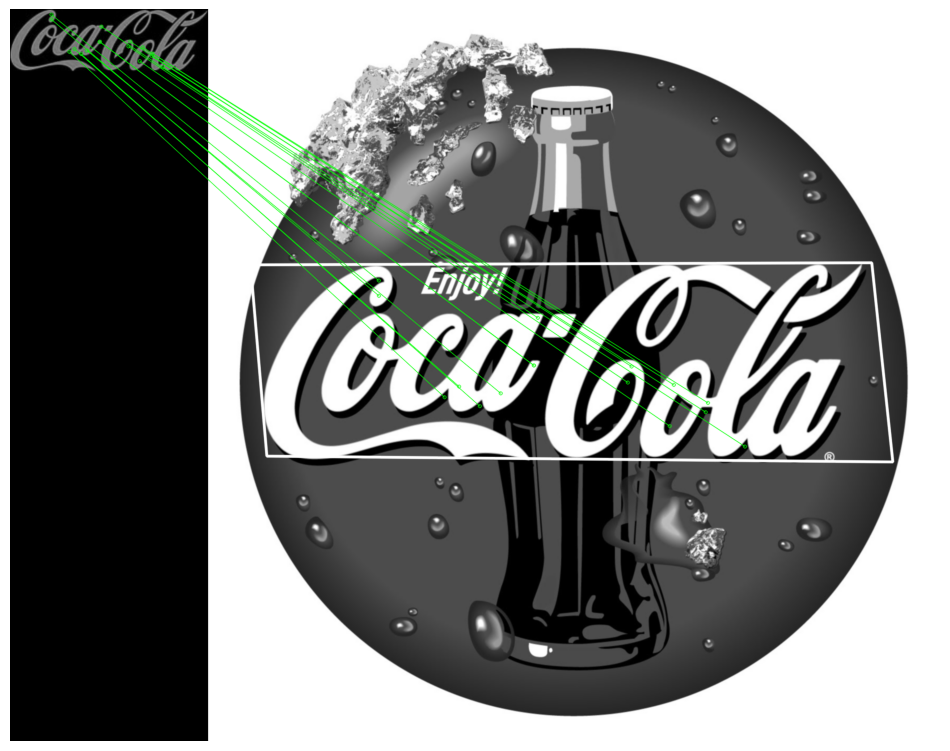

Resultado del procesamiento de coca_logo_1.png
-Cantidad de coincidencias: 48
-Cantidad de puntos en la homografía 41
-El ratio de inliers es 0.85
-El score de cantidad es 1.00
-El confidence score es 0.85


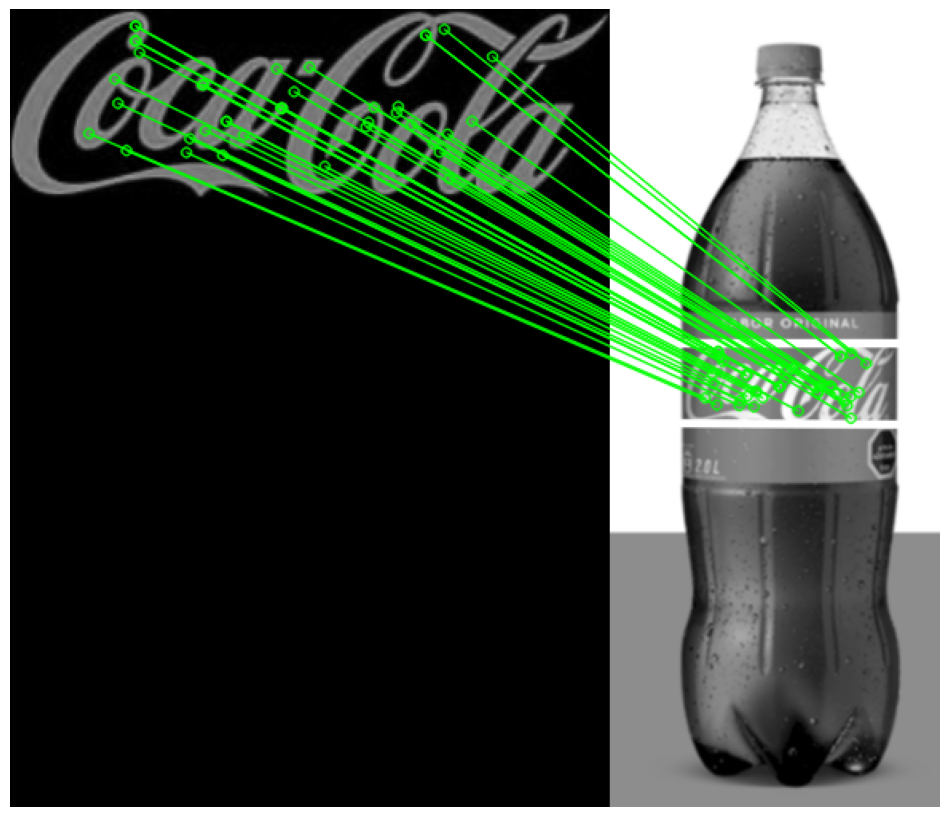

Resultado del procesamiento de coca_logo_2.png
-Cantidad de coincidencias: 52
-Cantidad de puntos en la homografía 33
-El ratio de inliers es 0.63
-El score de cantidad es 0.82
-El confidence score es 0.52


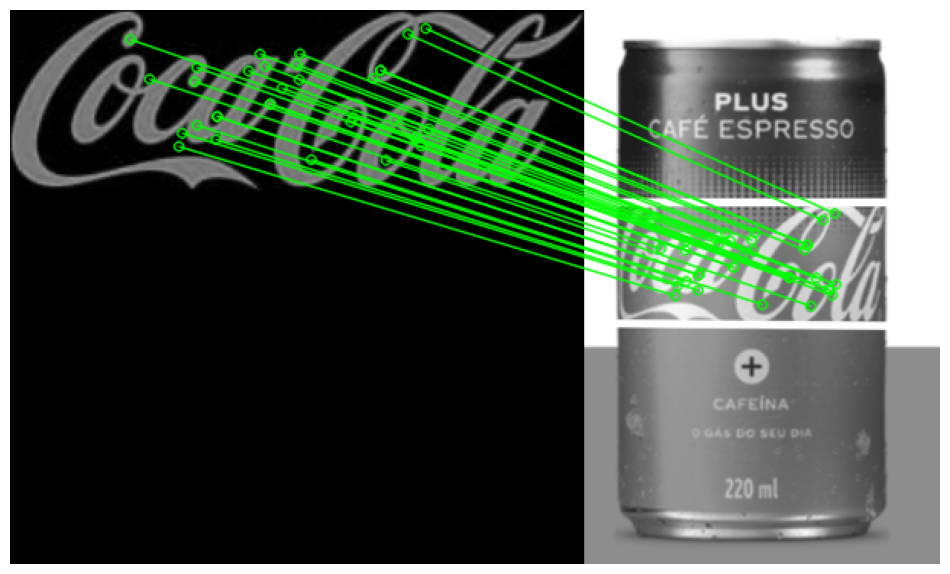

Resultado del procesamiento de coca_multi.png
-Cantidad de coincidencias: 13
-Cantidad de puntos en la homografía 7
-El ratio de inliers es 0.54
-El score de cantidad es 0.17
-El confidence score es 0.09


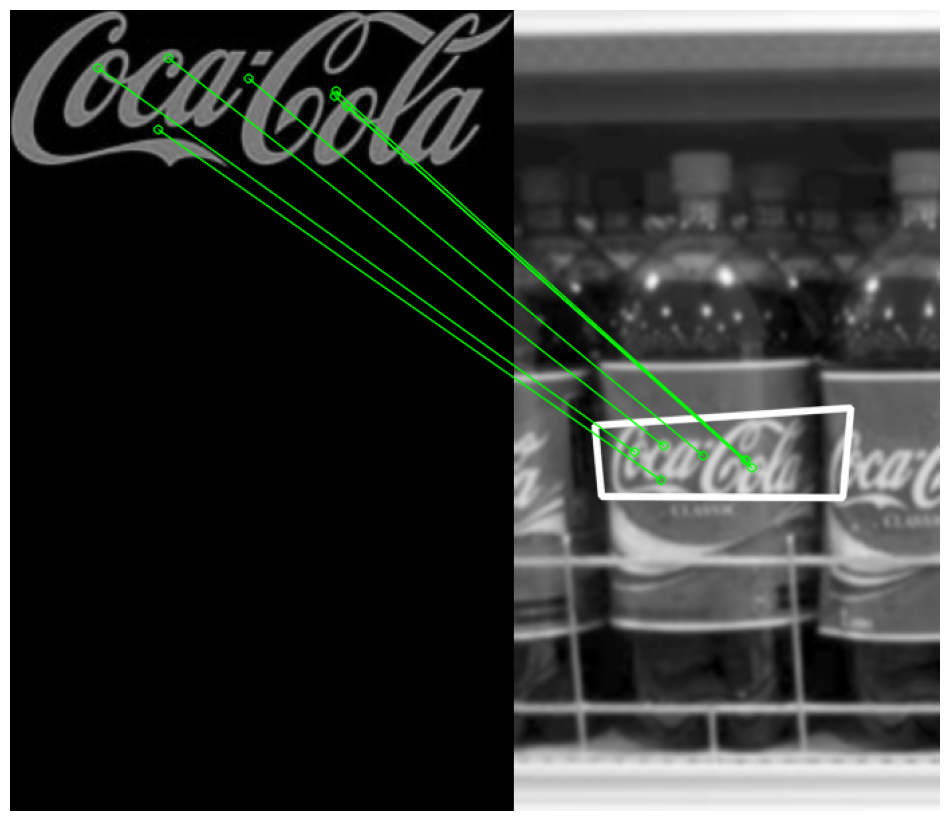

Resultado del procesamiento de coca_retro_1.png
-Cantidad de coincidencias: 41
-Cantidad de puntos en la homografía 15
-El ratio de inliers es 0.37
-El score de cantidad es 0.38
-El confidence score es 0.14


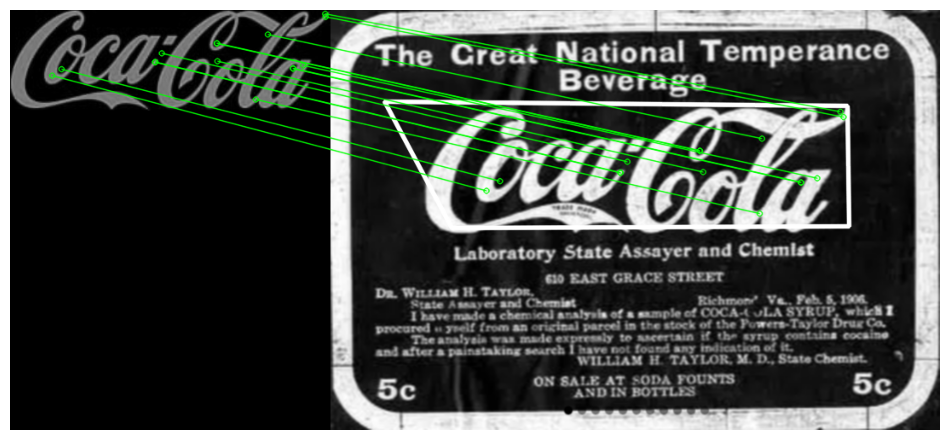

Resultado del procesamiento de coca_retro_2.png
-Cantidad de coincidencias: 18
-Cantidad de puntos en la homografía 14
-El ratio de inliers es 0.78
-El score de cantidad es 0.35
-El confidence score es 0.27


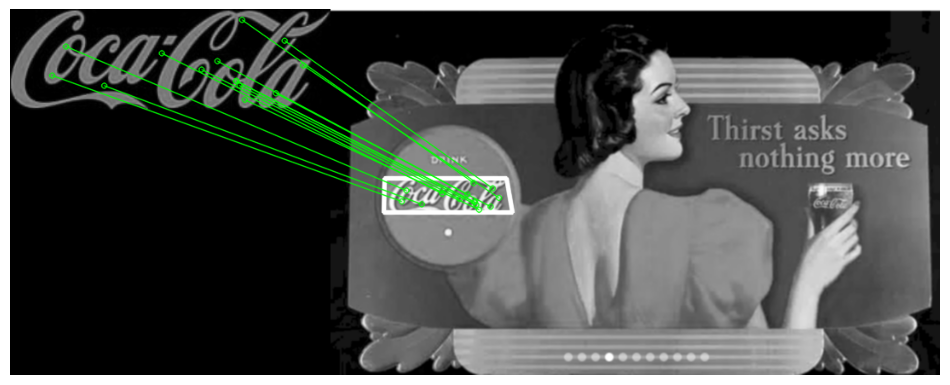

Resultado del procesamiento de logo_1.png
-Cantidad de coincidencias: 54
-Cantidad de puntos en la homografía 30
-El ratio de inliers es 0.56
-El score de cantidad es 0.75
-El confidence score es 0.42


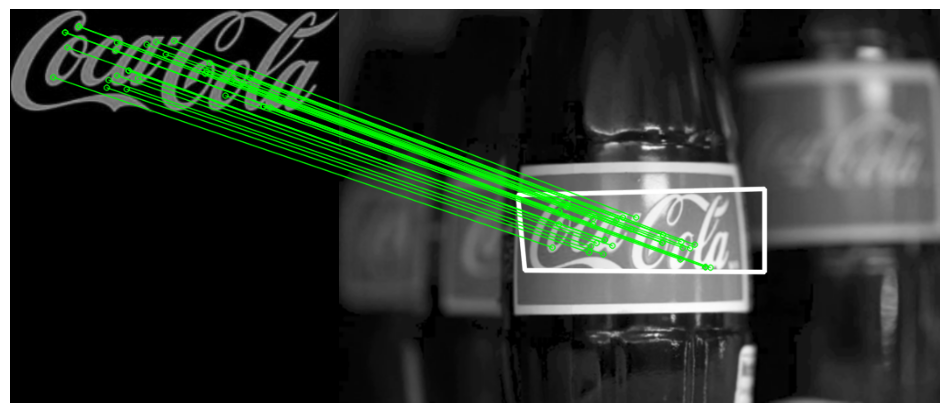

In [11]:
# Corremos la función de procesamiento para todas las imágenes preprocesadas

for image_name, image in prep_images.items():
    print(f'Resultado del procesamiento de {image_name}')
    process_img(pattern, image)